SESSION QUIZ 8.1

since you have no clue which words it could be here are the words in the wordslist, any of these words could be the answer: ('galaxy', 'supernova', 'blackhole', 'parallax', 'asteroid', 'comet', 'meteorite', 'jupiter', 'mercury', 'venus', 'saturn', 'mars', 'uranus', 'neptune', 'siriusa', 'lightyear', 'constellation', 'nebula', 'quasar', 'pulsar', 'whitedwarf', 'cluster', 'astronomicalunit', 'binarystar')

Let's start with a little disclaimer: This is a short storyline focussed game. 
The story is completely made up, the characters are not real.
All of this is purely for fun! I hope you will enjoy it :D



In 2018 a spaceship was launched and sent on a mission to see the most beautiful places in the entire universe.
After years of travel, you have finally reached your most important destination.
Let's take a look outside...


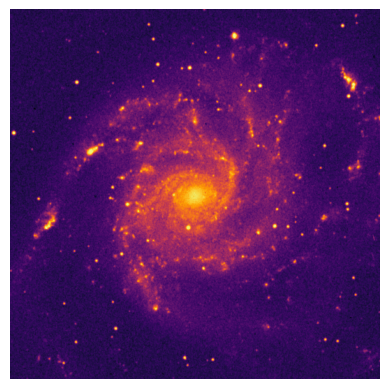


WOW... it's even more beautiful than you imagined.
But suddenly... you hear a loud bang!

LOUD BANG! *CRASHING SOUNDS*

OH NO! A meteorite hit your ship!
To survive, you must guess the correct word.
Each wrong guess breaks your ship further.
All words are astronomy-related.
Good luck!
 ^ 
(o)
/_\
 * 
______
_ _ _ _ _


Enter a letter:  a


 ^ 
(o)
/_\
______
_ _ _ _ _


Enter a letter:  e


 ^ 
(o)
/_\
______
_ e _ _ _


...

 ^ 
(o)
   
______
v e _ u _


Enter a letter:  n


 ^ 
(o)
   
______
v e n u _


Enter a letter:  s


 ^ 
(o)
   
______
v e n u s

YES! You saved your spaceship!
Your amazing journey can continue!


In [3]:
import random
from wordslist import words
from matplotlib import pyplot as plt
from astropy.io import fits
import numpy as np
import time

print("since you have no clue which words it could be here are the words in the wordslist, any of these words could be the answer:", words)

#creating a class for this game
class SpaceHangmanGame:
    #initializing the words we are working with for the code
    def __init__(self):
        self.words = words
        self.answer = random.choice(self.words)
        self.hint = ["_"] * len(self.answer)
        self.wrong_guesses = 0
        self.guessed_letters = set()
        self.is_running = True

        #the pictures of your space ship
        self.hangman_art = {
            0: (" ^ ", "(o)", "/_\\", " * "),
            1: (" ^ ", "(o)", "/_\\"),
            2: (" ^ ", "(o)", "/ \\"),
            3: (" ^ ", "(o)", "/  "),
            4: (" ^ ", "(o)", "   "),
            5: (" ^ ", "(o ", "   "),
            6: (" ^ ", "(  ", "   "),
            7: (" ^ ", "   ", "   "),
            8: ("   ", "  ", "  ")
        }

    #a way to slowly print all of the text fro dramatic effect and ambiance
    def slow_print(self, text, delay=0.03):
        for char in text:
            print(char, end='', flush=True)
            time.sleep(delay)
        print()

    #the monologue and information for the game, the story part of the game
    def show_intro(self):
        #little disclaimer for the person doing the game
        preface = ("\nLet's start with a little disclaimer: This is a short storyline focussed game. "
                   "\nThe story is completely made up, the characters are not real."
                   "\nAll of this is purely for fun! I hope you will enjoy it :D\n\n")

        self.slow_print(preface)

        #the start of the game, some information on where you are as the player
        monologue = ("\nIn 2018 a spaceship was launched and sent on a mission to see the most beautiful places in the entire universe."
                     "\nAfter years of travel, you have finally reached your most important destination."
                     "\nLet's take a look outside...")

        self.slow_print(monologue)

        #printing the image to emerge the player into the game
        self.show_image()

        #more monologue to appreciate the beauty, but then something happens...
        monologue2 = ("\nWOW... it's even more beautiful than you imagined."
                      "\nBut suddenly... you hear a loud bang!")

        self.slow_print(monologue2)

        #oh no! what is that sound???
        print("\nLOUD BANG! *CRASHING SOUNDS*")

        #what could the player possibly do to fix this?
        monologue3 = ("\nOH NO! A meteorite hit your ship!"
                      "\nTo survive, you must guess the correct word."
                      "\nEach wrong guess breaks your ship further."
                      "\nAll words are astronomy-related."
                      "\nGood luck!")

        self.slow_print(monologue3)

    #def to show the m101 image with the astronomical data we have seen many a times this course
    def show_image(self):
        hdulist = fits.open('m101.fits')
        dat = hdulist[0].data
        dat_float = dat.astype(np.float32)

        fig, ax = plt.subplots()
        ax.axis('off')
        ax.imshow(dat_float, cmap='inferno')
        plt.show()

    #a def to print the spaceship you are in which willl break down with every wrong answer
    def display_rocket(self):
        for line in self.hangman_art[self.wrong_guesses]:
            print(line)
        #printing a line under the spaceship so it looks better    
        print("______")

    #a def to display the hint
    def display_hint(self):
        print(" ".join(self.hint))

    #a def to display the answer
    def display_answer(self):
        print(" ".join(self.answer))

    #the guess of the player
    def get_guess(self):
        #letting the player enter a letter
        guess = input("Enter a letter: ").lower()

        #if the player inputs more than a singular letter, or maybe a symbol they will get an error message
        if len(guess) != 1 or not guess.isalpha():
            print("Error: invalid input, try a singular letter instead :D")
            return None

        #if the player has already guessed this letter they will be reminded that they already guessed said letter
        if guess in self.guessed_letters:
            print(f"{guess} was already guessed.")
            return None

        #stores the guessed letters in a list
        self.guessed_letters.add(guess)
        return guess

    #if the letter guessed is in the answer then the _ in the hint will be replaced by the correct letter    
    def process_guess(self, guess):
        if guess in self.answer:
            for i in range(len(self.answer)):
                if self.answer[i] == guess:
                    self.hint[i] = guess

        #If the guess is not in the answer a number will added to the wrong_giuesses which will give us the next(more broken down) picture of the spaceship
        else:
            self.wrong_guesses += 1

    #checks the game, if there are no more _ in the hint it means all the correct letters have beenb guessed and thus you have won
    def check_game_over(self):
        if "_" not in self.hint:
            self.display_rocket()
            self.display_answer()

            win_text = ("\nYES! You saved your spaceship!"
                        "\nYour amazing journey can continue!")

            #slow printing the text that you won, in theme ofcourse
            self.slow_print(win_text)
            #stops the hangman part of the game
            self.is_running = False

        #if you have more wrong guesses than the hangman pictures there are, all your lives are up so you did  not win
        elif self.wrong_guesses >= len(self.hangman_art) - 1:
            self.display_rocket()
            self.display_answer()

            lose_text = ("\nNO! Your spaceship has been destroyed, this means the end of your journey."
                         "\nGame over.")

            #slow printing the losing text
            self.slow_print(lose_text)
            self.is_running = False


    #the game, aka adding up all the individual parts
    def play(self):
        self.show_intro()

        #displaying the spaceship and your hint during the game
        while self.is_running:
            self.display_rocket()
            self.display_hint()

            guess = self.get_guess()
            if guess is None:
                continue

            self.process_guess(guess)
            self.check_game_over()


#running the game
if __name__ == "__main__":
    game = SpaceHangmanGame()
    game.play()